# Multi-Category End-to-End Inference

**Purpose.** Execute the complete portable inference contract across all 15 product categories using real MVTec images.

**Expected result.** One normal and one defective inspection per category, followed by a detailed backend-ready result for a representative sample.

**Platform connection.** This is the same `ml.inference.inspect_image` orchestration used by the application; only persistence and HTTP serialization are outside this Member 4 module.

In [1]:
from pathlib import Path
import json
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import JSON, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "ml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def locate_mvtec_root() -> Path:
    configured = os.getenv("MVTEC_DATASET_ROOT")
    candidates = [
        Path(configured).expanduser() if configured else None,
        PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai-github" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection1",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "MVTec AD was not found. Set MVTEC_DATASET_ROOT or place the dataset under "
        "data/raw/mvtec_anomaly_detection."
    )

DATASET_ROOT = locate_mvtec_root()
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def image_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

def first_test_image(category: str, label: str) -> Path:
    paths = image_files(DATASET_ROOT / category / "test" / label)
    if not paths:
        raise FileNotFoundError(f"No {category}/{label} test image was found.")
    return paths[0]

def first_defect(category: str) -> tuple[str, Path]:
    test_root = DATASET_ROOT / category / "test"
    defect_dirs = sorted(path for path in test_root.iterdir() if path.is_dir() and path.name != "good")
    for directory in defect_dirs:
        paths = image_files(directory)
        if paths:
            return directory.name, paths[0]
    raise FileNotFoundError(f"No defective test image was found for {category}.")

def mask_path_for(category: str, label: str, image_path: Path) -> Path | None:
    if label == "good":
        return None
    candidate = DATASET_ROOT / category / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return candidate if candidate.exists() else None

def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Project root: {PROJECT_ROOT}")
print(f"MVTec root:  {DATASET_ROOT}")

Project root: C:\Users\HP\Desktop\springboard\VisionInspectAI-team
MVTec root:  C:\Users\HP\Desktop\springboard\visioninspect-ai-github\data\raw\mvtec_anomaly_detection


In [2]:
from dataclasses import replace
from time import perf_counter

from ml.inference import inspect_image as inspect_image_runtime
from ml.model_registry import SUPPORTED_CATEGORIES
from ml.predict import build_inference_config

def portable_config(category: str):
    return replace(
        build_inference_config(category),
        use_padim_inference=False,
        use_openvino_inference=False,
        openvino_path=None,
        openvino_calibrator_path=None,
    )

rows = []
full_results = {}
for category in SUPPORTED_CATEGORIES:
    label, defect_path = first_defect(category)
    samples = [("good", first_test_image(category, "good")), (label, defect_path)]
    config = portable_config(category)
    for expected_label, path in samples:
        started = perf_counter()
        try:
            result = inspect_image_runtime(path, config)
            elapsed_ms = (perf_counter() - started) * 1000
            full_results[(category, expected_label)] = result
            rows.append(
                {
                    "category": category,
                    "expected": "Good" if expected_label == "good" else "Defective",
                    "expected_subtype": expected_label,
                    "prediction": result["prediction"],
                    "predicted_subtype": result["defect_type"],
                    "decision": result["decision"],
                    "anomaly_score": result["anomaly_score"],
                    "detection_confidence": result["detection_confidence"],
                    "severity": result["severity_score"],
                    "engine": result["active_inference_engine"],
                    "latency_ms": round(elapsed_ms, 1),
                    "error": None,
                }
            )
        except Exception as exc:
            rows.append(
                {
                    "category": category,
                    "expected": "Good" if expected_label == "good" else "Defective",
                    "expected_subtype": expected_label,
                    "prediction": None,
                    "predicted_subtype": None,
                    "decision": None,
                    "anomaly_score": None,
                    "detection_confidence": None,
                    "severity": None,
                    "engine": None,
                    "latency_ms": round((perf_counter() - started) * 1000, 1),
                    "error": str(exc),
                }
            )

smoke_df = pd.DataFrame(rows)
display(smoke_df)

,category,expected,expected_subtype,prediction,predicted_subtype,decision,anomaly_score,detection_confidence,severity,engine,latency_ms,error
0,bottle,Good,good,Good,good,Pass,0.006396,0.5527,0.00,baseline,372.9,None
1,bottle,Defective,broken_large,Defective,broken_large,Fail,0.047745,0.5886,65.27,baseline,2446.0,None
2,cable,Good,good,Good,good,Pass,0.040136,0.5514,0.00,baseline,151.9,None
3,cable,Defective,bent_wire,Good,good,Pass,0.041166,0.5504,0.00,baseline,155.2,None
4,capsule,Good,good,Defective,poke,Review,0.009213,0.5511,52.02,baseline,574.8,None
5,capsule,Defective,crack,Defective,squeeze,Review,0.009347,0.5512,49.52,baseline,190.0,None
6,carpet,Good,good,Good,good,Pass,0.004104,0.5576,0.00,baseline,130.2,None
7,carpet,Defective,color,Defective,color,Review,0.040546,0.5788,37.58,baseline,292.5,None
8,grid,Good,good,Good,good,Pass,0.013376,0.5535,0.00,baseline,105.7,None
9,grid,Defective,bent,Defective,broken,Review,0.020993,0.5542,48.33,baseline,384.3,None


<IPython.core.display.JSON object>

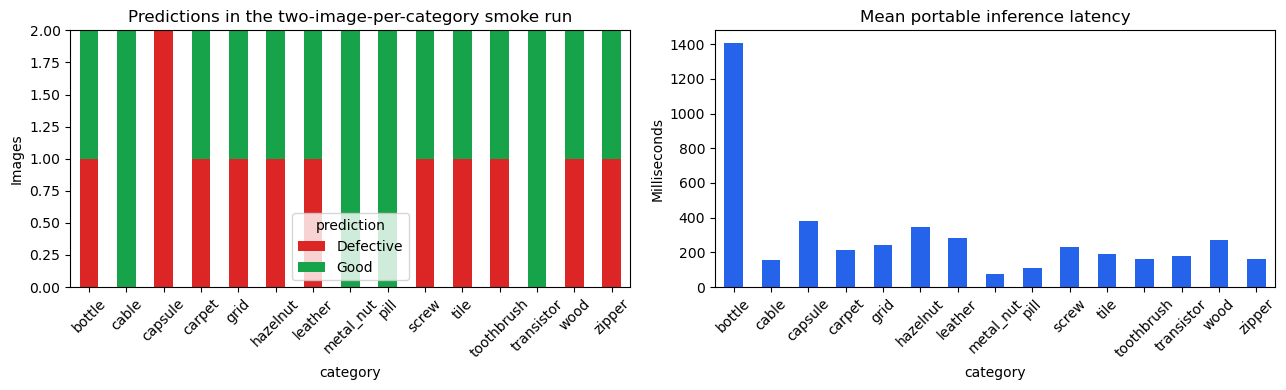

In [3]:
valid = smoke_df[smoke_df["error"].isna()].copy()
summary = {
    "categories_exercised": int(valid["category"].nunique()),
    "images_processed": int(len(valid)),
    "runtime_errors": int(smoke_df["error"].notna().sum()),
    "binary_matches_in_smoke_sample": int((valid["expected"] == valid["prediction"]).sum()),
    "binary_samples": int(len(valid)),
    "median_latency_ms": round(float(valid["latency_ms"].median()), 1),
    "p95_latency_ms": round(float(valid["latency_ms"].quantile(0.95)), 1),
}
display(JSON(summary))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
valid.groupby(["category", "prediction"]).size().unstack(fill_value=0).plot(kind="bar", stacked=True, ax=axes[0], color=["#dc2626", "#16a34a"])
axes[0].set_title("Predictions in the two-image-per-category smoke run")
axes[0].set_ylabel("Images")
axes[0].tick_params(axis="x", rotation=45)
valid.groupby("category")["latency_ms"].mean().plot(kind="bar", ax=axes[1], color="#2563eb")
axes[1].set_title("Mean portable inference latency")
axes[1].set_ylabel("Milliseconds")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [4]:
representative_key = next(
    key for key, value in full_results.items()
    if key[1] != "good" and value["prediction"] == "Defective"
)
representative = full_results[representative_key]
category, expected_subtype = representative_key

backend_ready = {
    "model_category": representative["model_category"],
    "prediction": representative["prediction"],
    "defect_type": representative["defect_type"],
    "detection_confidence": representative["detection_confidence"],
    "classification_confidence": representative["classification_confidence"],
    "anomaly_score": representative["anomaly_score"],
    "defect_area_ratio": representative["defect_area_ratio"],
    "class_probabilities": representative["class_probabilities"],
    "severity_components": representative["severity_components"],
    "severity_score": representative["severity_score"],
    "severity_level": representative["severity_level"],
    "decision": representative["decision"],
    "recommended_action": representative["recommended_action"],
    "model_used": representative["model_used"],
    "active_inference_engine": representative["active_inference_engine"],
    "fallback_used": representative["fallback_used"],
    "explainability": representative["explainability"],
}
display(Markdown(f"### Detailed result: `{category}/{expected_subtype}`"))
display(JSON(backend_ready))

### Detailed result: `bottle/broken_large`

<IPython.core.display.JSON object>

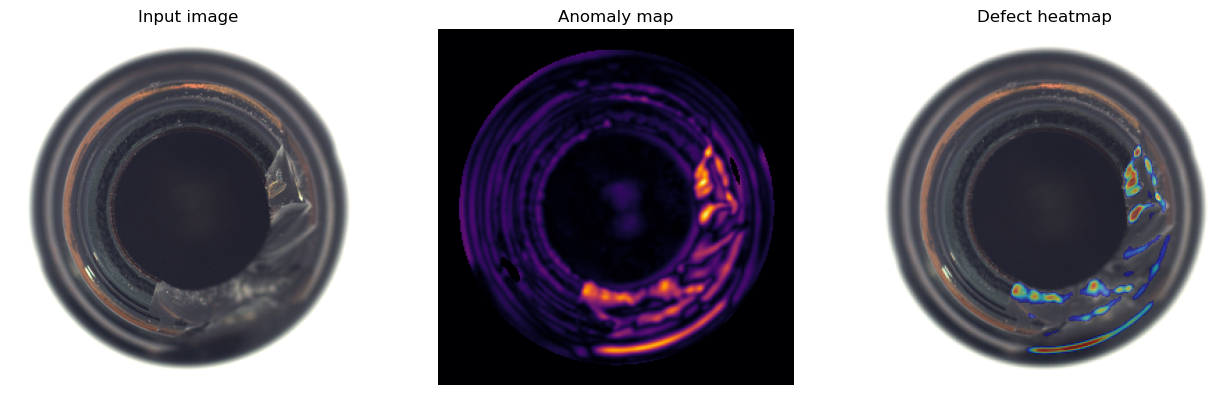

In [5]:
source_path = first_test_image(category, expected_subtype)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(read_rgb(source_path))
axes[0].set_title("Input image")
axes[1].imshow(representative["anomaly_map"], cmap="inferno")
axes[1].set_title("Anomaly map")
axes[2].imshow(cv2.cvtColor(representative["heatmap_image"], cv2.COLOR_BGR2RGB))
axes[2].set_title("Defect heatmap")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## How to interpret this run

This is an integration smoke test: it proves that every category can load its committed artifacts and return the full output schema. Two images per category are not enough to estimate accuracy. Formal metrics in the next notebook come from the recorded evaluation sets.

## What this demonstrates

- All 15 category configurations use one stable orchestration API.
- Detection, subtype classification, localization, severity, and QA decision fields are produced together.
- Runtime errors and latency are visible rather than hidden.
- Large image arrays stay inside the ML process; JSON-safe scalar fields are ready for the backend response.